In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

adata = ad.read_h5ad("../data_interim/final_filtered.h5ad")

In [4]:
sc.pp.highly_variable_genes(adata,layer="counts",flavor="seurat_v3",n_top_genes=3000)

In [5]:
sc.tl.pca(adata,n_comps=50,svd_solver='arpack',mask_var='highly_variable')

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_17800\2994898496.py:1: FutureWarning: The function pca_scatter is deprecated and will be removed in the future. Use :func:`scanpy.pl.pca` instead.
  sc.pl.pca_scatter(adata, color="major_cell_type")


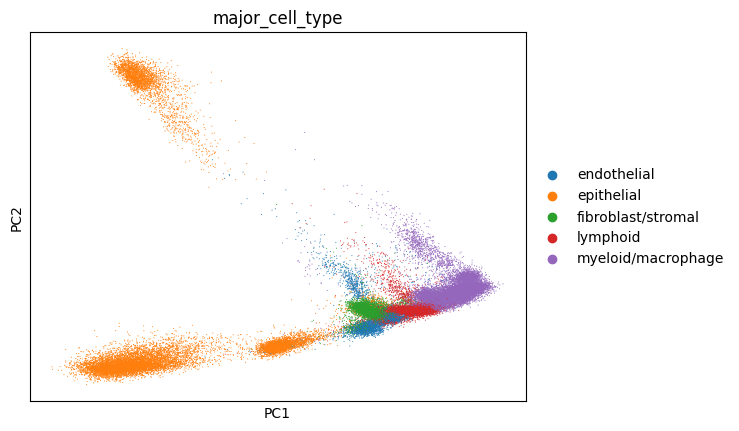

In [6]:
sc.pl.pca_scatter(adata, color="major_cell_type")

In [7]:
sc.pp.neighbors(adata, n_neighbors=30,n_pcs=20,random_state=2026)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sc.tl.leiden(adata,resolution=0.5,random_state=0,flavor="igraph",n_iterations=2,directed=False)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

In [10]:
sc.tl.paga(adata,groups="leiden")
sc.pl.paga(adata,plot=False)

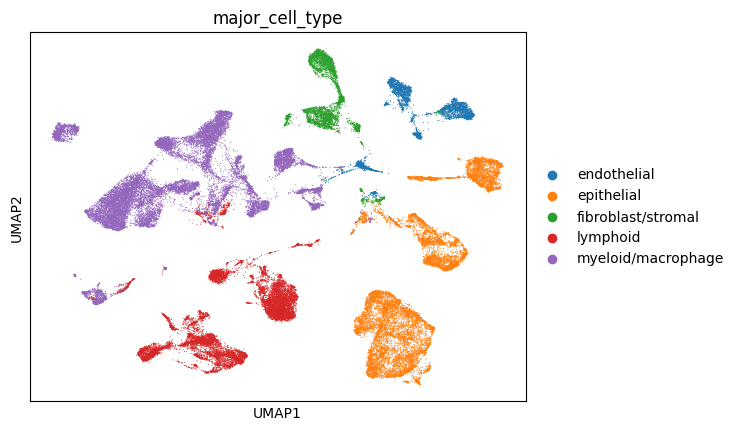

In [11]:
sc.tl.umap(adata, min_dist=0.3,init_pos='paga')
sc.pl.umap(adata,color='major_cell_type')

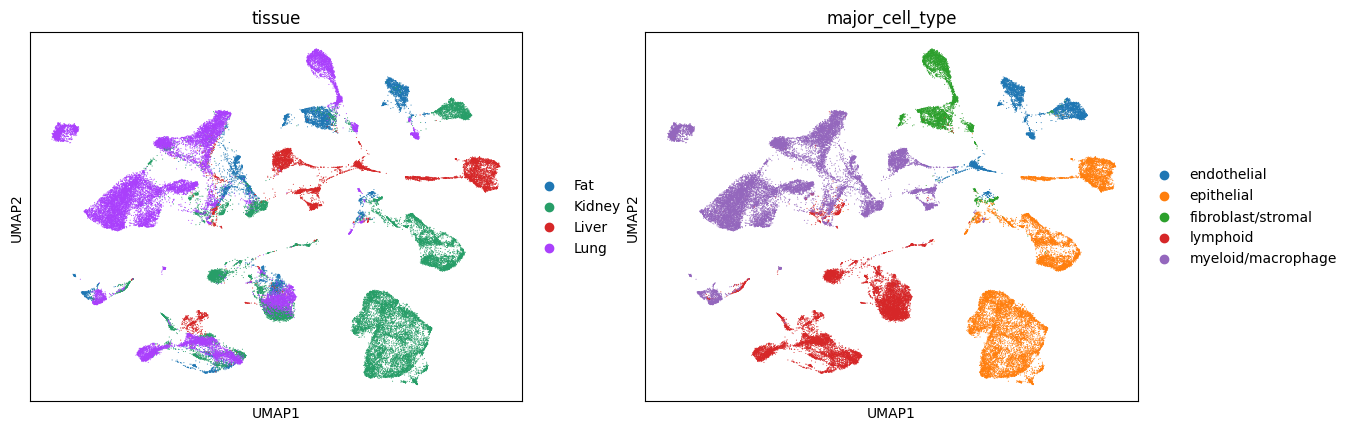

In [12]:
sc.pl.umap(adata, color=['tissue', 'major_cell_type'])

In [14]:
# 确定年龄分组
def assign_age_group(age):
    if age in [1, 3]:
        return "young"
    elif age in [18, 21]:
        return "middle"
    elif age in [24, 30]:
        return "old"
    else:
        return np.nan

mouse_level_pca["age_group"] = (mouse_level_pca["age_months"].apply(assign_age_group))

In [ ]:
print(mouse_level_pca[["mouse.id", "tissue", "major_cell_type","age_months", "age_group"]].head())

  mouse.id tissue major_cell_type  age_months age_group
0   1-M-62    Fat     endothelial         1.0     young
1   1-M-62    Fat     endothelial         3.0     young
2   1-M-62    Fat     endothelial        18.0    middle
3   1-M-62    Fat     endothelial        21.0    middle
4   1-M-62    Fat     endothelial        24.0       old


In [ ]:
print(mouse_level_pca["age_group"].value_counts())

age_group
young     420
middle    420
old       420
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(mouse_level_pca["tissue"],mouse_level_pca["age_group"]))

age_group        middle  old  young
tissue                             
Fat                  84   84     84
Heart_and_Aorta      84   84     84
Kidney               84   84     84
Liver                84   84     84
Lung                 84   84     84


In [20]:
os.makedirs("../results/pca",exist_ok=True)

mouse_level_pca.to_csv("../results/pca/mouse_level_pca.csv",index=False)

In [21]:
adata.write_h5ad("../data_processed/main_qc_pca.h5ad",compression="gzip")